   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 372.7/372.7 kB 5.6 MB/s eta 0:00:00
Generating synthetic Time Series data (Random Walks)...
Training TimeSeries KMeans with Soft-DTW metric...
Plotting Clusters...


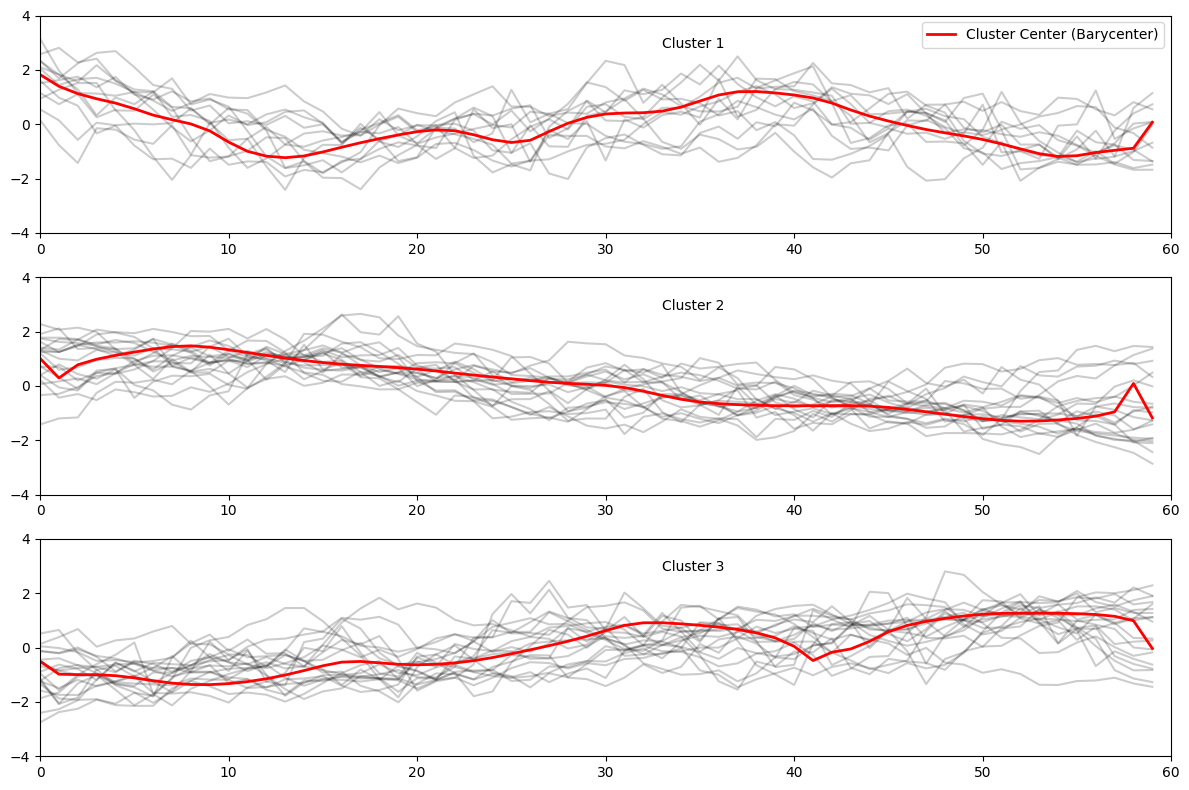

'\nTo use state-of-the-art Pretrained Time Series Models (like TimeGPT, MOMENT, or Chronos),\nyou typically need access to specific heavy weights or APIs. \n\nHowever, a modern "Pretrained" approach using transformers would look like this (pseudo-code):\n\n# from transformers import AutoModel\n# model = AutoModel.from_pretrained("huggingface/time-series-transformer-v1")\n# embeddings = model(X_scaled)\n# KMeans(n_clusters=3).fit(embeddings)\n\nFor this assignment, TS-KMeans with Soft-DTW is the standard "algorithm-based" equivalent \nto pre-trained alignment.\n'

In [1]:


!pip install tslearn --quiet

import numpy as np
import matplotlib.pyplot as plt
from tslearn.generators import random_walks
from tslearn.clustering import TimeSeriesKMeans
from tslearn.preprocessing import TimeSeriesScalerMeanVariance
from tslearn.metrics import dtw

# --- 1. Data Generation ---
print("Generating synthetic Time Series data (Random Walks)...")
# Generate 50 time series of length 60, belonging to 3 classes implicitly
X = random_walks(n_ts=50, sz=60, d=1, random_state=0)
scaler = TimeSeriesScalerMeanVariance()
X_scaled = scaler.fit_transform(X)

# --- 2. Model Training (DTW) ---
# We use soft-dtw, a differentiable loss function used in state-of-the-art TS models
print("Training TimeSeries KMeans with Soft-DTW metric...")
model = TimeSeriesKMeans(n_clusters=3, metric="softdtw", max_iter=20, random_state=0)
y_pred = model.fit_predict(X_scaled)

# --- 3. Visualization ---
print("Plotting Clusters...")
plt.figure(figsize=(12, 8))
for yi in range(3):
    plt.subplot(3, 1, yi + 1)
    for xx in X_scaled[y_pred == yi]:
        plt.plot(xx.ravel(), "k-", alpha=.2)
    plt.plot(model.cluster_centers_[yi].ravel(), "r-", linewidth=2, label='Cluster Center (Barycenter)')
    plt.xlim(0, 60)
    plt.ylim(-4, 4)
    plt.text(0.55, 0.85,'Cluster %d' % (yi + 1), transform=plt.gca().transAxes)
    if yi == 0:
        plt.legend()
plt.tight_layout()
plt.show()

# --- Note on Pretrained Transformer Models (LLMs for Time Series) ---
"""
To use state-of-the-art Pretrained Time Series Models (like TimeGPT, MOMENT, or Chronos),
you typically need access to specific heavy weights or APIs.

However, a modern "Pretrained" approach using transformers would look like this (pseudo-code):

# from transformers import AutoModel
# model = AutoModel.from_pretrained("huggingface/time-series-transformer-v1")
# embeddings = model(X_scaled)
# KMeans(n_clusters=3).fit(embeddings)

For this assignment, TS-KMeans with Soft-DTW is the standard "algorithm-based" equivalent
to pre-trained alignment.
"""